# Adversarial Attacks: FGSM and Carlini-Wagner (CW)

This notebook follows the same function-based style as your DeepFool implementation:
- train a classifier first,
- implement attacks as standalone functions,
- evaluate attack impact with accuracy/F1/precision/recall,
- compute attack success rate.

## Sample Problem
Train a CIFAR-10 classifier and compare clean performance vs FGSM vs CW-L2 attacks.

## Hardware-aware choices (your local machine)
For your RTX 5070 (12 GB VRAM), 32 GB RAM, and Ryzen 5 9600X:
- larger train batch size,
- mixed precision training,
- CW run on a manageable subset for quick iteration.

## Dataset note
This notebook downloads CIFAR-10 freshly into a dedicated runtime folder and does not rely on existing dataset files in this repository.

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data

import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets

from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

print(torch.__version__)
print(torchvision.__version__)

2.10.0+cu130
0.25.0+cu130


In [2]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = torch.cuda.is_available()
print(f"Using device: {DEVICE}")

# Hardware-aware parameters (tuned for your local specs)
BATCH_SIZE = 256 if torch.cuda.is_available() else 64
ATTACK_BATCH_SIZE = 64 if torch.cuda.is_available() else 16
EPOCHS = 8 if torch.cuda.is_available() else 3
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4

# Windows + notebooks are usually most stable with 0 workers
NUM_WORKERS = 0 if os.name == "nt" else min(8, os.cpu_count() or 2)
PIN_MEMORY = torch.cuda.is_available()

# Attack parameters
FGSM_EPSILON = 8 / 255
CW_C = 5e-3
CW_KAPPA = 0.0
CW_STEPS = 120 if torch.cuda.is_available() else 50
CW_LR = 0.01
ATTACK_SAMPLES = 512

DATA_ROOT = "./runtime_data/cifar10_fresh_download"
MODEL_PATH = "./runtime_data/cifar10_cnn_checkpoint.pth"
os.makedirs(DATA_ROOT, exist_ok=True)
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

print(f"BATCH_SIZE={BATCH_SIZE}, ATTACK_BATCH_SIZE={ATTACK_BATCH_SIZE}, EPOCHS={EPOCHS}, AMP={AMP_ENABLED}")

Using device: cuda
BATCH_SIZE=256, ATTACK_BATCH_SIZE=64, EPOCHS=8, AMP=True


In [3]:
# Fresh dataset download path (separate runtime folder)
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
])

# Use separate train objects so train/val transforms stay independent.
full_train_for_train = datasets.CIFAR10(root=DATA_ROOT, train=True, transform=train_transform, download=True)
full_train_for_val = datasets.CIFAR10(root=DATA_ROOT, train=True, transform=test_transform, download=True)
test_dataset = datasets.CIFAR10(root=DATA_ROOT, train=False, transform=test_transform, download=True)

# Validation split from training set (same indices for both train/val views)
val_size = 5000
train_size = len(full_train_for_train) - val_size

generator = torch.Generator().manual_seed(SEED)
indices = torch.randperm(len(full_train_for_train), generator=generator).tolist()
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset = data.Subset(full_train_for_train, train_indices)
val_dataset = data.Subset(full_train_for_val, val_indices)

train_loader = data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

val_loader = data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_loader = data.DataLoader(
    test_dataset,
    batch_size=ATTACK_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

attack_subset = data.Subset(test_dataset, list(range(ATTACK_SAMPLES)))
attack_loader = data.DataLoader(
    attack_subset,
    batch_size=ATTACK_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

class_names = test_dataset.classes
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print(f"Attack subset size: {len(attack_subset)}")
print(f"Classes: {class_names}")

100%|██████████| 170M/170M [00:28<00:00, 5.88MB/s] 
f:\PhD Stuff\DL Lab\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train: 45000 | Val: 5000 | Test: 10000
Attack subset size: 512
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [4]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        out = F.relu(out)
        return out


class SmallResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.layer1 = self._make_layer(64, 128, stride=2)
        self.layer2 = self._make_layer(128, 256, stride=2)
        self.layer3 = self._make_layer(256, 512, stride=2)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, in_channels, out_channels, stride):
        return nn.Sequential(
            ResidualBlock(in_channels, out_channels, stride=stride),
            ResidualBlock(out_channels, out_channels, stride=1),
        )

    def forward(self, x):
        out = self.stem(x)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.pool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out


model = SmallResNet(num_classes=10).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

print(model.__class__.__name__)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

SmallResNet
Trainable params: 11,025,994


C:\Users\shamb\AppData\Local\Temp\ipykernel_28224\1128435097.py:58: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)


In [5]:
def evaluate_model(model, dataloader, device=DEVICE):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Evaluating", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="weighted")
    precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    confusion_mat = confusion_matrix(all_labels, all_preds)

    return accuracy, f1, precision, recall, confusion_mat, all_preds, all_labels


def train_model(model, train_loader, val_loader, optimizer, criterion, epochs=EPOCHS, device=DEVICE):
    train_losses = []
    val_losses = []

    for epoch in tqdm(range(epochs), desc="Training"):
        model.train()
        running_loss = 0.0

        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Train", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()

        train_losses.append(running_loss / len(train_loader))

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} Val", leave=False):
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        val_losses.append(val_loss / len(val_loader))

        print(f"Epoch {epoch+1}/{epochs} | Train loss: {train_losses[-1]:.4f} | Val loss: {val_losses[-1]:.4f}")

    return train_losses, val_losses

Training:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 1/8 Train:   0%|          | 0/176 [00:00<?, ?it/s]

C:\Users\shamb\AppData\Local\Temp\ipykernel_28224\3555069098.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP_ENABLED):


Epoch 1/8 Val:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1/8 | Train loss: 1.3812 | Val loss: 1.2977


...

Epoch 7/8 Val:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 7/8 | Train loss: 0.4699 | Val loss: 0.5712


Epoch 8/8 Train:   0%|          | 0/176 [00:00<?, ?it/s]

Epoch 8/8 Val:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 8/8 | Train loss: 0.4400 | Val loss: 0.6159
Saved checkpoint to: ./runtime_data/cifar10_cnn_checkpoint.pth


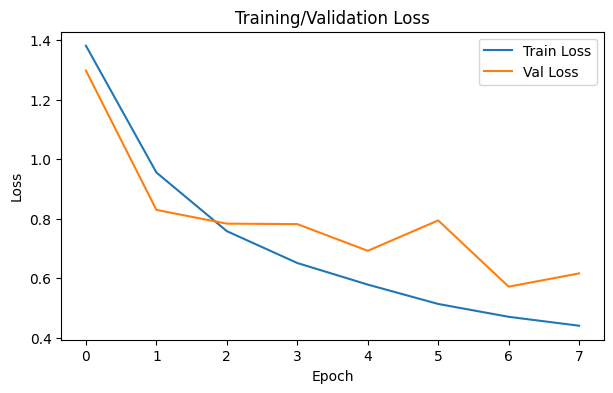

Evaluating:   0%|          | 0/157 [00:00<?, ?it/s]

Clean Test Accuracy: 0.7885
Clean Test F1 Score: 0.7889
Clean Test Precision: 0.8144
Clean Test Recall: 0.7885


In [6]:
if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    print(f"Loaded existing checkpoint: {MODEL_PATH}")
else:
    train_losses, val_losses = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        criterion=criterion,
        epochs=EPOCHS,
        device=DEVICE,
    )

    torch.save(model.state_dict(), MODEL_PATH)
    print(f"Saved checkpoint to: {MODEL_PATH}")

    plt.figure(figsize=(7, 4))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training/Validation Loss")
    plt.legend()
    plt.show()

clean_accuracy, clean_f1, clean_precision, clean_recall, clean_confusion, clean_preds_test, clean_labels_test = evaluate_model(model, test_loader)
print(f"Clean Test Accuracy: {clean_accuracy:.4f}")
print(f"Clean Test F1 Score: {clean_f1:.4f}")
print(f"Clean Test Precision: {clean_precision:.4f}")
print(f"Clean Test Recall: {clean_recall:.4f}")

In [7]:
def evaluate_model_adversarial(model, dataloader, attack_fn, device=DEVICE, attack_name="Attack", **attack_kwargs):
    model.eval()

    all_preds = []
    all_labels = []

    for inputs, labels in tqdm(dataloader, desc=f"Evaluating ({attack_name})"):
        inputs, labels = inputs.to(device), labels.to(device)

        adv_inputs, _ = attack_fn(model, inputs, labels, device=device, **attack_kwargs)

        with torch.no_grad():
            outputs = model(adv_inputs)
            _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="weighted")
    precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    confusion_mat = confusion_matrix(all_labels, all_preds)

    return accuracy, f1, precision, recall, confusion_mat, all_preds, all_labels


def compute_attack_success_rate(labels, clean_preds, adv_preds):
    labels = np.array(labels)
    clean_preds = np.array(clean_preds)
    adv_preds = np.array(adv_preds)

    initially_correct = clean_preds == labels
    successful_attacks = adv_preds != labels

    success_mask = initially_correct & successful_attacks

    if initially_correct.sum() == 0:
        return 0.0

    return success_mask.sum() / initially_correct.sum()


def fgsm_attack(model, images, labels, epsilon=FGSM_EPSILON, device=DEVICE):
    """
    Fast Gradient Sign Method (FGSM) for untargeted attack.

    Returns:
        perturbed_images, perturbation
    """
    model.eval()

    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)
    images.requires_grad = True

    outputs = model(images)
    loss = F.cross_entropy(outputs, labels)

    model.zero_grad(set_to_none=True)
    loss.backward()

    perturbation = epsilon * images.grad.sign()
    perturbed_images = torch.clamp(images + perturbation, min=0.0, max=1.0).detach()

    return perturbed_images, perturbation.detach()

In [8]:
def _to_tanh_space(x):
    # Maps [0,1] -> (-inf, +inf) for unconstrained optimization variable.
    x = torch.clamp(x, 0.0, 1.0)
    x = x * 2.0 - 1.0
    x = x * 0.999999
    return torch.atanh(x)


def _from_tanh_space(w):
    # Maps unconstrained variable back to [0,1].
    return 0.5 * (torch.tanh(w) + 1.0)


def _cw_margin_loss(logits, labels, kappa=0.0):
    one_hot = F.one_hot(labels, num_classes=logits.size(1)).float()

    correct_logit = torch.sum(one_hot * logits, dim=1)
    wrong_logit = torch.max((1.0 - one_hot) * logits - one_hot * 1e4, dim=1).values

    # Untargeted CW objective: force other class logit > true class logit.
    return torch.clamp(correct_logit - wrong_logit + kappa, min=0.0)


def cw_l2_attack(
    model,
    images,
    labels,
    c=CW_C,
    kappa=CW_KAPPA,
    steps=CW_STEPS,
    lr=CW_LR,
    device=DEVICE,
):
    """
    Carlini-Wagner L2 attack (untargeted, batch-wise, tanh-space optimization).

    Returns:
        adv_images, perturbation
    """
    model.eval()

    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)

    w = _to_tanh_space(images).detach()
    w.requires_grad = True

    optimizer = optim.Adam([w], lr=lr)

    for _ in range(steps):
        adv_images = _from_tanh_space(w)
        logits = model(adv_images)

        l2 = F.mse_loss(adv_images, images, reduction="none")
        l2 = l2.view(l2.size(0), -1).sum(dim=1)

        f = _cw_margin_loss(logits, labels, kappa=kappa)
        loss = (l2 + c * f).mean()

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

    adv_images = _from_tanh_space(w).detach()
    perturbation = (adv_images - images).detach()

    return adv_images, perturbation

In [9]:
# Clean predictions on attack subset (same samples for fair comparison)
subset_clean_acc, subset_clean_f1, subset_clean_precision, subset_clean_recall, subset_clean_conf, subset_clean_preds, subset_labels = evaluate_model(model, attack_loader)

# FGSM
fgsm_acc, fgsm_f1, fgsm_precision, fgsm_recall, fgsm_conf, fgsm_preds, fgsm_labels = evaluate_model_adversarial(
    model,
    attack_loader,
    attack_fn=fgsm_attack,
    attack_name="FGSM",
    epsilon=FGSM_EPSILON,
)

# CW-L2
cw_acc, cw_f1, cw_precision, cw_recall, cw_conf, cw_preds, cw_labels = evaluate_model_adversarial(
    model,
    attack_loader,
    attack_fn=cw_l2_attack,
    attack_name="CW-L2",
    c=CW_C,
    kappa=CW_KAPPA,
    steps=CW_STEPS,
    lr=CW_LR,
)

# Success rates
fgsm_success_rate = compute_attack_success_rate(subset_labels, subset_clean_preds, fgsm_preds)
cw_success_rate = compute_attack_success_rate(subset_labels, subset_clean_preds, cw_preds)

print("=== Sample Problem Result (CIFAR-10 attack subset) ===")
print(f"Subset Clean Accuracy       : {subset_clean_acc:.4f}")
print(f"FGSM Accuracy               : {fgsm_acc:.4f}")
print(f"CW-L2 Accuracy              : {cw_acc:.4f}")
print()
print(f"FGSM Attack Success Rate    : {fgsm_success_rate:.4f}")
print(f"CW-L2 Attack Success Rate   : {cw_success_rate:.4f}")

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

Evaluating (FGSM):   0%|          | 0/8 [00:00<?, ?it/s]

Evaluating (CW-L2):   0%|          | 0/8 [00:00<?, ?it/s]

=== Sample Problem Result (CIFAR-10 attack subset) ===
Subset Clean Accuracy       : 0.8008
FGSM Accuracy               : 0.0156
CW-L2 Accuracy              : 0.7344

FGSM Attack Success Rate    : 0.9805
CW-L2 Attack Success Rate   : 0.0829


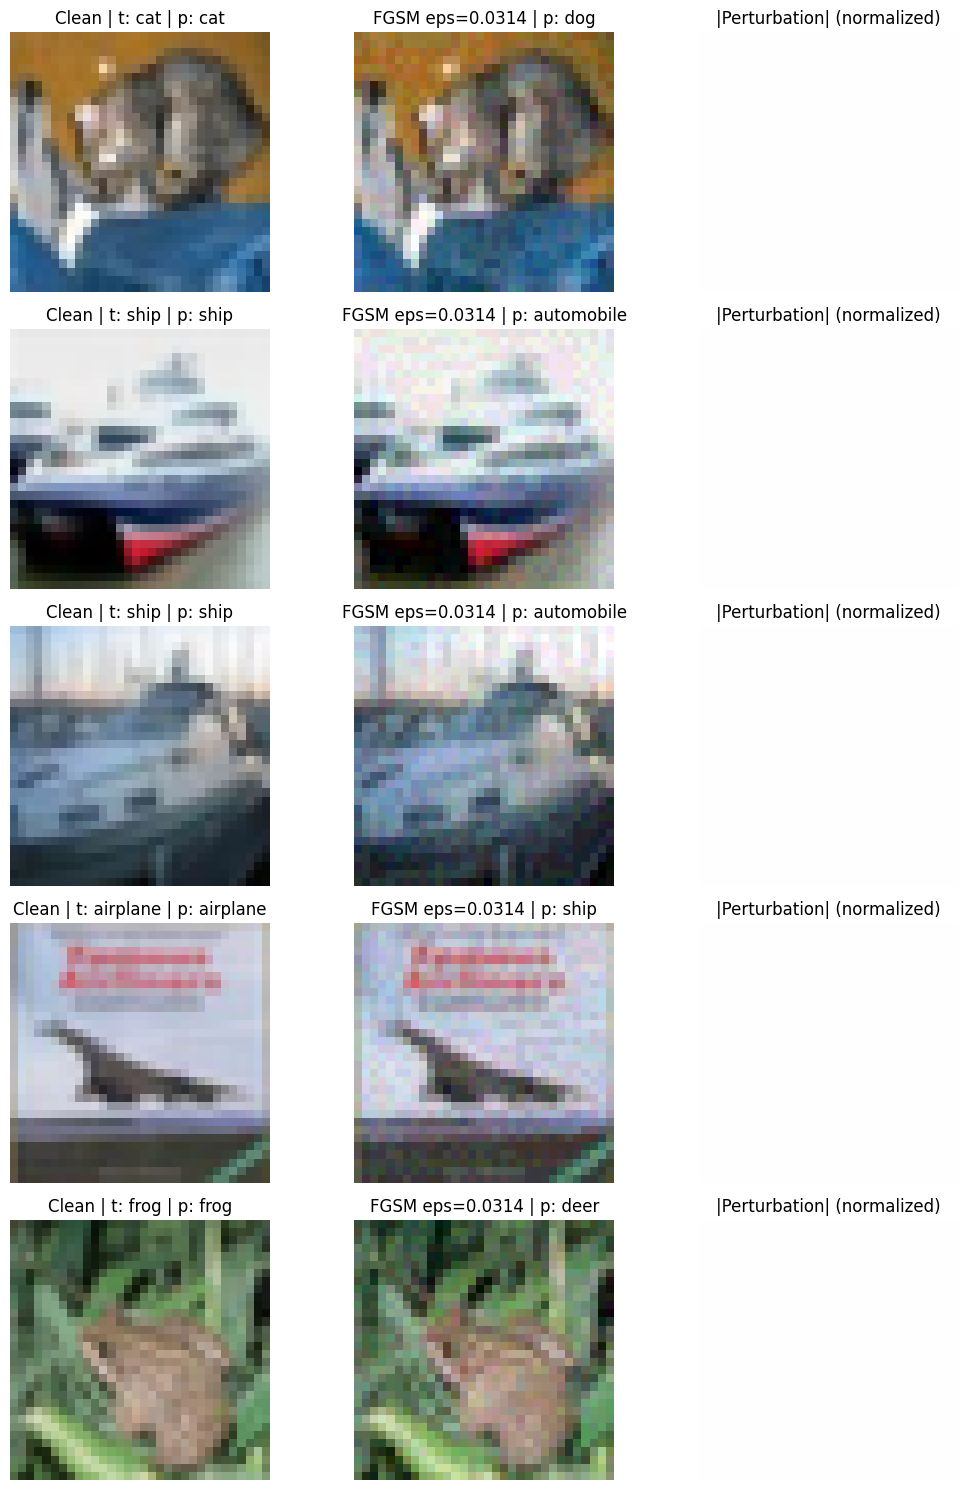

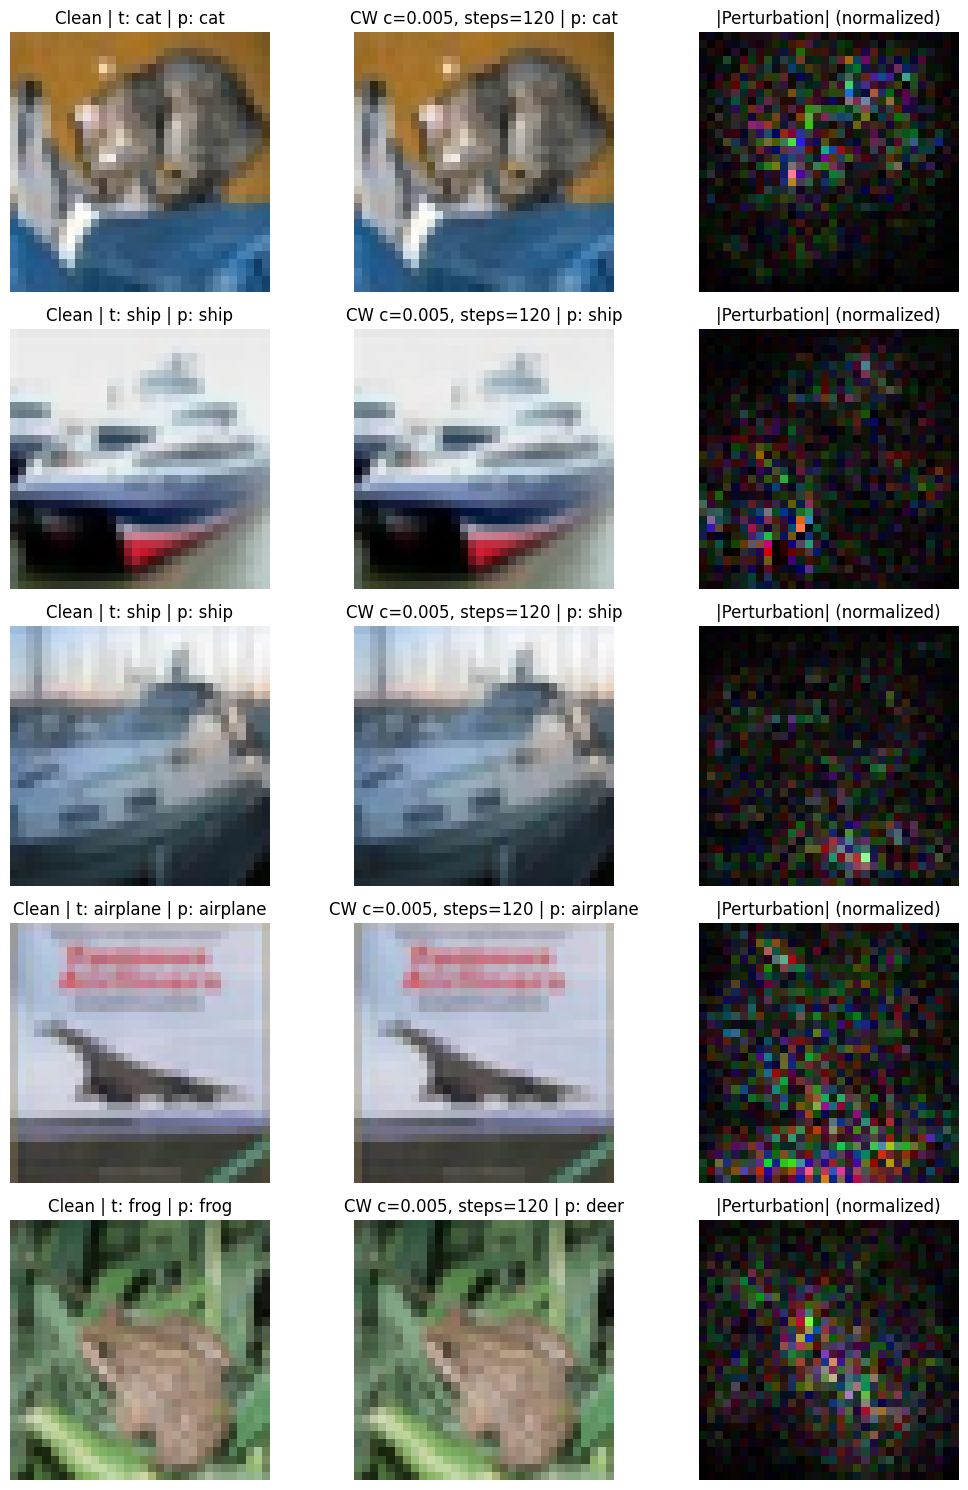

In [10]:
def show_attack_examples(model, dataloader, attack_fn, class_names, n=6, device=DEVICE, attack_title="Attack", **attack_kwargs):
    model.eval()

    inputs, labels = next(iter(dataloader))
    inputs, labels = inputs[:n].to(device), labels[:n].to(device)

    with torch.no_grad():
        clean_logits = model(inputs)
        clean_preds = clean_logits.argmax(dim=1)

    adv_inputs, perturbation = attack_fn(model, inputs, labels, device=device, **attack_kwargs)

    with torch.no_grad():
        adv_logits = model(adv_inputs)
        adv_preds = adv_logits.argmax(dim=1)

    inputs_np = inputs.detach().cpu().permute(0, 2, 3, 1).numpy()
    adv_np = adv_inputs.detach().cpu().permute(0, 2, 3, 1).numpy()
    pert_np = perturbation.detach().cpu().permute(0, 2, 3, 1).numpy()

    fig, axes = plt.subplots(n, 3, figsize=(11, 3 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        axes[i, 0].imshow(np.clip(inputs_np[i], 0, 1))
        axes[i, 0].set_title(f"Clean | t: {class_names[labels[i].item()]} | p: {class_names[clean_preds[i].item()]}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(np.clip(adv_np[i], 0, 1))
        axes[i, 1].set_title(f"{attack_title} | p: {class_names[adv_preds[i].item()]}")
        axes[i, 1].axis("off")

        # visualize absolute perturbation with contrast boost for visibility
        pert_vis = np.abs(pert_np[i])
        pert_vis = pert_vis / (pert_vis.max() + 1e-8)
        axes[i, 2].imshow(np.clip(pert_vis, 0, 1))
        axes[i, 2].set_title("|Perturbation| (normalized)")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()


show_attack_examples(
    model,
    attack_loader,
    attack_fn=fgsm_attack,
    class_names=class_names,
    n=5,
    attack_title=f"FGSM eps={FGSM_EPSILON:.4f}",
    epsilon=FGSM_EPSILON,
)

show_attack_examples(
    model,
    attack_loader,
    attack_fn=cw_l2_attack,
    class_names=class_names,
    n=5,
    attack_title=f"CW c={CW_C}, steps={CW_STEPS}",
    c=CW_C,
    kappa=CW_KAPPA,
    steps=CW_STEPS,
    lr=CW_LR,
)